# Predictive Customer Lifetime Value (CLTV) Analysis

## Objective

This notebook develops a predictive approach to estimate customer lifetime value over a 12-month horizon.

The analysis uses historical customer transaction behavior to identify factors associated with future customer value and support customer segmentation.

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("../Data/Ecommerce_Dataset .csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

C:\Users\imsan\AppData\Local\Temp\ipykernel_13396\3779868339.py:1: DtypeWarning: Columns (0: order_id, 1: customer_id, 2: transaction_date, 3: product_category, 4: signup_date, 5: acquisition_channel, 6: country) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../Data/Ecommerce_Dataset .csv")


Dataset loaded successfully!
Rows: 143545
Columns: 10


In [6]:
# Convert customer purchase dates to datetime

customer_features["first_purchase"] = pd.to_datetime(
    customer_features["first_purchase"]
)

customer_features["last_purchase"] = pd.to_datetime(
    customer_features["last_purchase"]
)

print("Purchase dates converted successfully!")

Purchase dates converted successfully!


C:\Users\imsan\AppData\Local\Temp\ipykernel_13396\734411363.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  customer_features["first_purchase"] = pd.to_datetime(
C:\Users\imsan\AppData\Local\Temp\ipykernel_13396\734411363.py:7: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  customer_features["last_purchase"] = pd.to_datetime(


In [7]:
# Calculate customer tenure in days

customer_features["tenure_days"] = (
    customer_features["last_purchase"]
    - customer_features["first_purchase"]
).dt.days

customer_features.head()

,customer_id,total_revenue,total_orders,total_quantity,average_order_value,first_purchase,last_purchase,tenure_days
0,CUST000001,579.92,1,4.0,579.92,2023-05-24,2023-05-24,0
1,CUST000002,1472.17,7,18.0,210.31,2024-10-12,2024-04-09,-186
2,CUST000003,359.76,1,3.0,359.76,2023-10-21,2023-10-21,0
3,CUST000004,1633.92,8,17.0,204.24,2023-07-16,2023-12-04,141
4,CUST000005,209.94,2,3.0,104.97,2023-04-13,2023-06-02,50


In [8]:
# Check customer tenure

print("Minimum tenure:", customer_features["tenure_days"].min(), "days")
print("Maximum tenure:", customer_features["tenure_days"].max(), "days")
print("Average tenure:", round(customer_features["tenure_days"].mean(), 2), "days")

Minimum tenure: -574 days
Maximum tenure: 433 days
Average tenure: -0.95 days


In [9]:
# Calculate monthly purchase frequency

customer_features["purchase_frequency"] = (
    customer_features["total_orders"]
    / (customer_features["tenure_days"].replace(0, 1) / 30)
)

customer_features[[
    "customer_id",
    "total_orders",
    "tenure_days",
    "purchase_frequency"
]].head()

,customer_id,total_orders,tenure_days,purchase_frequency
0,CUST000001,1,0,30.000000
1,CUST000002,7,-186,-1.129032
2,CUST000003,1,0,30.000000
3,CUST000004,8,141,1.702128
4,CUST000005,2,50,1.200000


In [10]:
# Check customer-level features

customer_features.describe()

,total_revenue,total_orders,total_quantity,average_order_value,first_purchase,last_purchase,tenure_days,purchase_frequency
count,19076.000000,19076.000000,19076.000000,19076.000000,19076,19076,19076.000000,19076.000000
mean,1219.456944,3.762424,9.408104,324.239704,2024-03-02 17:15:09.624659,2024-03-01 18:32:45.695114,-0.946110,7.909549
min,10.410000,1.000000,1.000000,10.410000,2023-01-10 00:00:00,2023-01-09 00:00:00,-574.000000,-60.000000
25%,424.507500,1.000000,4.000000,212.995833,2023-09-15 00:00:00,2023-09-09 00:00:00,-35.000000,-1.636364
50%,895.890000,3.000000,7.000000,307.131000,2024-03-14 00:00:00,2024-03-09 00:00:00,0.000000,1.875000
75%,1691.910000,5.000000,13.000000,410.915000,2024-09-01 00:00:00,2024-08-31 00:00:00,35.000000,30.000000
max,8434.190000,22.000000,66.000000,999.120000,2024-12-31 00:00:00,2024-12-31 00:00:00,433.000000,60.000000
std,1101.889895,3.092945,8.021831,164.381327,NaN,NaN,70.521545,13.814533


In [11]:
# Check missing values in customer features

customer_features.isnull().sum()

customer_id            0
total_revenue          0
total_orders           0
total_quantity         0
average_order_value    0
first_purchase         0
last_purchase          0
tenure_days            0
purchase_frequency     0
dtype: int64

In [12]:
# Define the dataset observation period

observation_end = df["transaction_date"].max()

print("Last transaction date:", observation_end)

Last transaction date: 9/9/2024


In [14]:
# Convert observation end date to datetime

observation_end = pd.to_datetime(df["transaction_date"]).max()

print("Last transaction date:", observation_end)
print("Data type:", type(observation_end))

Last transaction date: 2024-12-31 00:00:00
Data type: <class 'pandas.Timestamp'>


C:\Users\imsan\AppData\Local\Temp\ipykernel_13396\2151957032.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  observation_end = pd.to_datetime(df["transaction_date"]).max()


In [15]:
# Define the observation cutoff

observation_cutoff = observation_end - pd.DateOffset(months=12)

print("Observation cutoff:", observation_cutoff)

Observation cutoff: 2023-12-31 00:00:00


In [16]:
model_transactions = df[
    pd.to_datetime(df["transaction_date"]) <= observation_cutoff
].copy()

print("Transactions available for modeling:", len(model_transactions))

Transactions available for modeling: 27607


C:\Users\imsan\AppData\Local\Temp\ipykernel_13396\2384603835.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  pd.to_datetime(df["transaction_date"]) <= observation_cutoff


In [17]:
# Create customer features using only historical data

model_features = model_transactions.groupby("customer_id").agg(
    total_revenue=("revenue", "sum"),
    total_orders=("order_id", "nunique"),
    total_quantity=("quantity", "sum"),
    average_order_value=("revenue", "mean"),
    first_purchase=("transaction_date", "min"),
    last_purchase=("transaction_date", "max")
).reset_index()

# Make sure dates are datetime
model_features["first_purchase"] = pd.to_datetime(
    model_features["first_purchase"]
)
model_features["last_purchase"] = pd.to_datetime(
    model_features["last_purchase"]
)

# Calculate customer tenure
model_features["tenure_days"] = (
    model_features["last_purchase"]
    - model_features["first_purchase"]
).dt.days

# Calculate monthly purchase frequency
model_features["purchase_frequency"] = (
    model_features["total_orders"]
    / (model_features["tenure_days"].replace(0, 1) / 30)
)

model_features.head()

C:\Users\imsan\AppData\Local\Temp\ipykernel_13396\812960753.py:13: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  model_features["first_purchase"] = pd.to_datetime(
C:\Users\imsan\AppData\Local\Temp\ipykernel_13396\812960753.py:16: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  model_features["last_purchase"] = pd.to_datetime(


,customer_id,total_revenue,total_orders,total_quantity,average_order_value,first_purchase,last_purchase,tenure_days,purchase_frequency
0,CUST000001,579.92,1,4.0,579.92,2023-05-24,2023-05-24,0,30.000000
1,CUST000003,359.76,1,3.0,359.76,2023-10-21,2023-10-21,0,30.000000
2,CUST000004,1633.92,8,17.0,204.24,2023-07-16,2023-12-04,141,1.702128
3,CUST000005,209.94,2,3.0,104.97,2023-04-13,2023-06-02,50,1.200000
4,CUST000007,222.77,1,1.0,222.77,2023-03-06,2023-03-06,0,30.000000


In [18]:
# Transactions after the observation cutoff

future_transactions = df[
    (pd.to_datetime(df["transaction_date"]) > observation_cutoff) &
    (pd.to_datetime(df["transaction_date"]) <= observation_end)
].copy()

print("Future transactions:", len(future_transactions))

Future transactions: 44165


C:\Users\imsan\AppData\Local\Temp\ipykernel_13396\3157967309.py:4: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  (pd.to_datetime(df["transaction_date"]) > observation_cutoff) &
C:\Users\imsan\AppData\Local\Temp\ipykernel_13396\3157967309.py:5: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  (pd.to_datetime(df["transaction_date"]) <= observation_end)


In [19]:
# Calculate future 12-month revenue for each customer

future_revenue = (
    future_transactions
    .groupby("customer_id")["revenue"]
    .sum()
    .reset_index()
)

future_revenue.columns = [
    "customer_id",
    "future_12m_revenue"
]

future_revenue.head()

,customer_id,future_12m_revenue
0,CUST000002,1472.17
1,CUST000006,163.54
2,CUST000008,101.54
3,CUST000010,1959.99
4,CUST000011,782.88


In [21]:
# Combine historical features with future revenue

model_data = model_features.merge(
    future_revenue,
    on="customer_id",
    how="left"
)

# Customers with no future purchases have zero future revenue
model_data["future_12m_revenue"] = (
    model_data["future_12m_revenue"].fillna(0)
)

print("Model dataset shape:", model_data.shape)

model_data.head()

Model dataset shape: (9061, 10)


,customer_id,total_revenue,total_orders,total_quantity,average_order_value,first_purchase,last_purchase,tenure_days,purchase_frequency,future_12m_revenue
0,CUST000001,579.92,1,4.0,579.92,2023-05-24,2023-05-24,0,30.000000,0.0
1,CUST000003,359.76,1,3.0,359.76,2023-10-21,2023-10-21,0,30.000000,0.0
2,CUST000004,1633.92,8,17.0,204.24,2023-07-16,2023-12-04,141,1.702128,0.0
3,CUST000005,209.94,2,3.0,104.97,2023-04-13,2023-06-02,50,1.200000,0.0
4,CUST000007,222.77,1,1.0,222.77,2023-03-06,2023-03-06,0,30.000000,0.0


In [22]:
# Check the 12-month future revenue target

print(model_data["future_12m_revenue"].describe())

print(
    "\nCustomers with future revenue:",
    (model_data["future_12m_revenue"] > 0).sum()
)

print(
    "Customers with zero future revenue:",
    (model_data["future_12m_revenue"] == 0).sum()
)

count    9061.000000
mean      435.135385
std       900.428951
min         0.000000
25%         0.000000
50%         0.000000
75%       428.240000
max      6008.310000
Name: future_12m_revenue, dtype: float64

Customers with future revenue: 2873
Customers with zero future revenue: 6188


In [23]:
# Select features for the predictive model

features = [
    "total_revenue",
    "total_orders",
    "total_quantity",
    "average_order_value",
    "tenure_days",
    "purchase_frequency"
]

X = model_data[features]
y = model_data["future_12m_revenue"]

print("Features:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['total_revenue', 'total_orders', 'total_quantity', 'average_order_value', 'tenure_days', 'purchase_frequency']

X shape: (9061, 6)
y shape: (9061,)


In [24]:
# Check for missing and infinite values

print("Missing values:")
print(X.isnull().sum())

print("\nInfinite values:")
print(np.isinf(X).sum())

Missing values:
total_revenue          0
total_orders           0
total_quantity         0
average_order_value    0
tenure_days            0
purchase_frequency     0
dtype: int64

Infinite values:
total_revenue          0
total_orders           0
total_quantity         0
average_order_value    0
tenure_days            0
purchase_frequency     0
dtype: int64


In [25]:
# Clean infinite values

X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(0)

print("Missing values after cleaning:")
print(X.isnull().sum())

Missing values after cleaning:
total_revenue          0
total_orders           0
total_quantity         0
average_order_value    0
tenure_days            0
purchase_frequency     0
dtype: int64


In [26]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 7248
Testing rows: 1813


In [27]:
# Train Random Forest regression model

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [28]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 1813


In [29]:
# Evaluate model performance

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-----------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Model Performance
-----------------
MAE : 677.51
RMSE: 1014.59
R²  : -0.2217


In [30]:
# Compare actual and predicted revenue

comparison = pd.DataFrame({
    "Actual_12M_Revenue": y_test.values,
    "Predicted_12M_Revenue": y_pred
})

comparison.head(10)

,Actual_12M_Revenue,Predicted_12M_Revenue
0,0.00,149.53000
1,0.00,203.04210
2,0.00,92.61395
3,1456.41,114.48140
4,0.00,124.54360
5,0.00,63.31390
6,2509.00,902.35445
7,0.00,383.75235
8,694.35,562.14295
9,0.00,744.56610


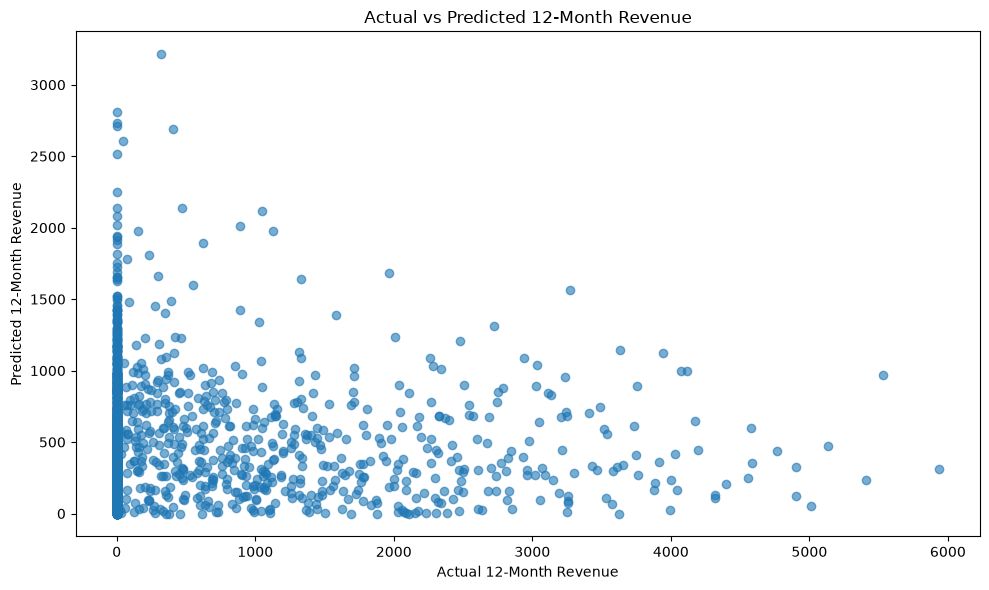

In [31]:
# Actual vs Predicted Revenue

plt.figure(figsize=(10, 6))

plt.scatter(
    comparison["Actual_12M_Revenue"],
    comparison["Predicted_12M_Revenue"],
    alpha=0.6
)

plt.xlabel("Actual 12-Month Revenue")
plt.ylabel("Predicted 12-Month Revenue")
plt.title("Actual vs Predicted 12-Month Revenue")

plt.tight_layout()
plt.show()

In [32]:
# Feature importance

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
3,average_order_value,0.311783
0,total_revenue,0.302129
5,purchase_frequency,0.137092
4,tenure_days,0.134116
2,total_quantity,0.093788
1,total_orders,0.021091


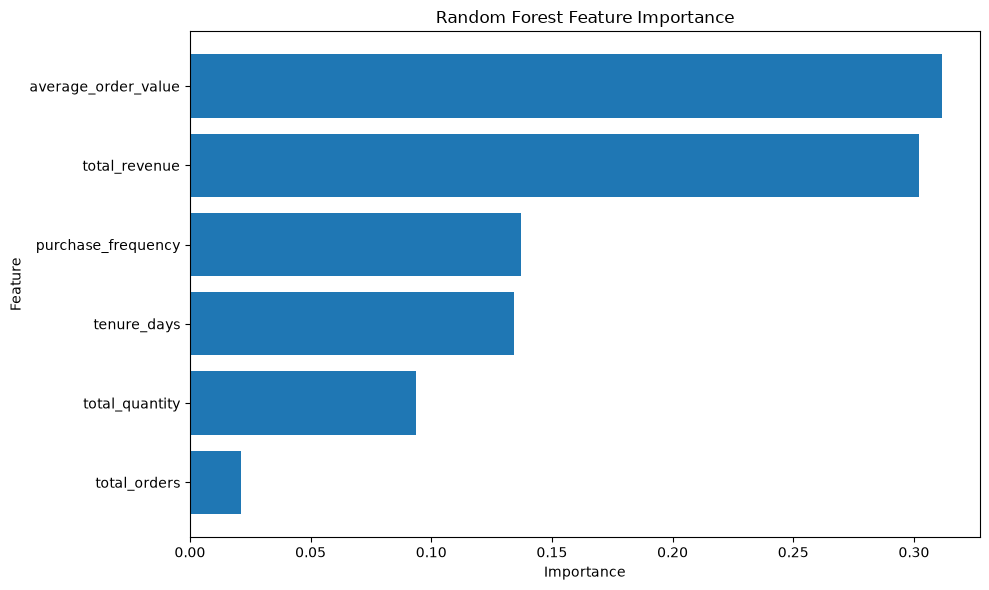

In [33]:
# Plot feature importance

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [34]:
# Generate predicted 12-month CLTV for all customers

model_data["predicted_12m_cltv"] = model.predict(
    model_data[features]
)

model_data[
    [
        "customer_id",
        "future_12m_revenue",
        "predicted_12m_cltv"
    ]
].head(10)

,customer_id,future_12m_revenue,predicted_12m_cltv
0,CUST000001,0.00,65.688455
1,CUST000003,0.00,212.997700
2,CUST000004,0.00,214.367000
3,CUST000005,0.00,172.761150
4,CUST000007,0.00,0.000000
5,CUST000009,0.00,231.203750
6,CUST000011,782.88,849.930700
7,CUST000014,0.00,5.561400
8,CUST000016,0.00,393.595050
9,CUST000018,1732.63,1358.666150


In [35]:
# Summary of predicted 12-month CLTV

model_data["predicted_12m_cltv"].describe()

count    9061.000000
mean      452.130137
std       562.443031
min         0.000000
25%        96.396495
50%       242.172900
75%       579.787800
max      4275.117800
Name: predicted_12m_cltv, dtype: float64

In [36]:
# Create CLTV customer segments

model_data["cltv_segment"] = pd.qcut(
    model_data["predicted_12m_cltv"],
    q=4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "Very High Value"
    ],
    duplicates="drop"
)

model_data[
    [
        "customer_id",
        "predicted_12m_cltv",
        "cltv_segment"
    ]
].head(10)

,customer_id,predicted_12m_cltv,cltv_segment
0,CUST000001,65.688455,Low Value
1,CUST000003,212.997700,Medium Value
2,CUST000004,214.367000,Medium Value
3,CUST000005,172.761150,Medium Value
4,CUST000007,0.000000,Low Value
5,CUST000009,231.203750,Medium Value
6,CUST000011,849.930700,Very High Value
7,CUST000014,5.561400,Low Value
8,CUST000016,393.595050,High Value
9,CUST000018,1358.666150,Very High Value


In [37]:
# Customer count by CLTV segment

segment_counts = (
    model_data["cltv_segment"]
    .value_counts()
    .sort_index()
)

segment_counts

cltv_segment
Low Value          2266
Medium Value       2265
High Value         2265
Very High Value    2265
Name: count, dtype: int64

In [38]:
# Analyze customer segments

segment_analysis = (
    model_data
    .groupby("cltv_segment", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        average_predicted_cltv=("predicted_12m_cltv", "mean"),
        total_predicted_cltv=("predicted_12m_cltv", "sum"),
        average_historical_revenue=("total_revenue", "mean"),
        average_orders=("total_orders", "mean")
    )
    .reset_index()
)

segment_analysis

,cltv_segment,customers,average_predicted_cltv,total_predicted_cltv,average_historical_revenue,average_orders
0,Low Value,2266,40.705087,9.223773e+04,625.057992,1.844219
1,Medium Value,2265,163.255623,3.697740e+05,982.540764,3.003532
2,High Value,2265,378.014231,8.562022e+05,1121.384274,3.494923
3,Very High Value,2265,1226.727252,2.778537e+06,1246.733969,3.845033


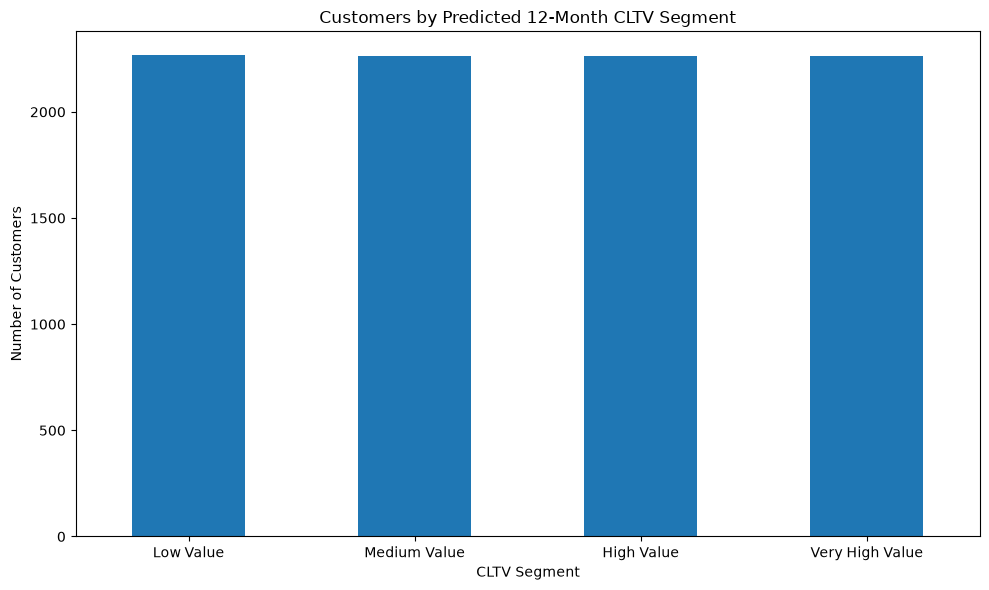

In [39]:
# Visualize customer CLTV segments

plt.figure(figsize=(10, 6))

segment_counts.plot(kind="bar")

plt.title("Customers by Predicted 12-Month CLTV Segment")
plt.xlabel("CLTV Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [40]:
# Top 10 customers by predicted 12-month CLTV

top_customers = (
    model_data
    .sort_values(
        "predicted_12m_cltv",
        ascending=False
    )
    .head(10)
)

top_customers[
    [
        "customer_id",
        "total_revenue",
        "total_orders",
        "average_order_value",
        "purchase_frequency",
        "predicted_12m_cltv",
        "cltv_segment"
    ]
]

,customer_id,total_revenue,total_orders,average_order_value,purchase_frequency,predicted_12m_cltv,cltv_segment
7397,CUST016337,1932.19,5,386.438000,2.586207,4275.11780,Very High Value
3152,CUST006992,197.64,1,197.640000,30.000000,3899.30340,Very High Value
4653,CUST010262,878.48,4,219.620000,-1.764706,3787.43630,Very High Value
8877,CUST019532,762.55,3,254.183333,3.913043,3742.39925,Very High Value
3515,CUST007758,355.65,1,355.650000,30.000000,3638.88480,Very High Value
3269,CUST007228,1568.06,4,392.015000,-13.333333,3633.60290,Very High Value
2118,CUST004702,1751.28,4,437.820000,2.448980,3615.51790,Very High Value
5258,CUST011633,1279.15,4,319.787500,2.181818,3609.80080,Very High Value
8241,CUST018229,2450.83,8,306.353750,2.637363,3558.89345,Very High Value
2544,CUST005645,2744.22,9,304.913333,-1.054688,3507.46705,Very High Value


# Business Insights

## Predictive CLTV Findings

The predictive CLTV model estimates the expected customer revenue over the next 12 months based on historical purchasing behavior.

### Key Findings

1. **Customer value varies significantly**
   - Customers were segmented into Low Value, Medium Value, High Value, and Very High Value groups based on predicted 12-month CLTV.

2. **Historical purchasing behavior is important**
   - Customer transaction history, including revenue, order frequency, order value, and purchase activity, provides useful information for predicting future customer value.

3. **High-value customers**
   - Customers with higher predicted CLTV represent an important group for retention and targeted marketing strategies.

4. **Low-value customers**
   - Lower predicted CLTV customers can be targeted with appropriate engagement and conversion strategies to increase future value.

5. **Model evaluation**
   - MAE, RMSE, and R² were used to evaluate the predictive model. These metrics should be considered when interpreting the reliability of the predictions.

## Business Recommendations

- Prioritize retention strategies for Very High Value and High Value customers.
- Develop personalized offers for valuable customer segments.
- Monitor customers with declining purchase activity.
- Use predicted CLTV to support customer segmentation and marketing budget allocation.
- Continue collecting customer transaction data to improve future CLTV predictions.

In [41]:
# Final model performance

print("Final Model Performance")
print("-----------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Final Model Performance
-----------------------
MAE  : 677.51
RMSE : 1014.59
R²   : -0.2217
